# TFG V4 — Cost-phase + local mixer

This version implements a simple variational strategy to increase the probability of measuring valid windows without using Grover. The idea is to assign a phase according to each window cost and then mix amplitude only between neighboring indices.

## Represented problem

- `0`: free cell.
- `1`: occupied cell.
- Each index `i` represents a valid starting position for a window `M` inside the grid `N`.
- A window is valid if all its cells are `0`.

For each index, define:

```text
C(i) = number of ones in window_i
```

therefore `C(i)=0` means that the window is valid.

## Circuit flow

1. Prepare a uniform superposition over window indices.
2. Reversibly load `window_i` into the register `m`.
3. Apply a cost-dependent phase: each `1` bit in the window contributes a phase `theta`.
4. Uncompute `window_i` so that the phase remains encoded on `idx`.
5. Apply a local mixer on `idx`, usually between geometrically neighboring windows.
6. Repeat the block several times.

## Main registers

- `n`: fixed grid.
- `idx`: index of the candidate window.
- `m`: window temporarily loaded to compute the phase.

## Purpose of this version

V4 studies whether the `cost-phase + mixer` block concentrates amplitude on windows with `C(i)=0`. The code is modular so that the mixer, the parameters `theta`, `mixer_angle`, `repetitions`, and the 1D/2D/ND geometry can be changed easily.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import numpy as np
import qiskit

from math import prod
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import MCXGate, UnitaryGate

print(qiskit.__version__)

2.3.1


In [2]:
# =========================================================
# Parameters configurables del experimento principal
# =========================================================

N = [8]          # grid size per dimension
M = [2]          # window/job size per dimension
occupied_coords = [(0), (3), (4), (5)]  # occupied coordinates (0-based)

# Cost-phase + mixer block
theta = np.pi / 6   # valor tuneado para el caso principal 1D actual
mixer_angle = 0.30  # valor tuneado para aumentar P_valid en el caso principal
repetitions = 4
use_cost_phase = True
use_mixer = True

# Available mixers:
# - "local_geometric": rotates between neighboring valid windows in the ND geometry
# - "linear_valid": rotates between consecutive valid indices
# - "rx_all": simple prototype with RX on all idx bits; it can leak amplitude to invalid indices
mixer_method = "local_geometric"

## Tuned parameters for the main example

The main example uses a small 1D grid so that the circuit is easy to inspect and simulate:

```python
N = [8]
M = [2]
occupied_coords = [0, 3, 4, 5]
```

In this case there are `W=7` possible windows and two valid windows. With the current parameters:

```python
theta = np.pi / 6
mixer_angle = 0.30
repetitions = 4
```

Statevector simulation increases the total probability of measuring a valid window from approximately `0.2857` to `0.8981`.

These values are specific to the example. If the grid, window size, or mixer changes, the parameters should be swept again because the dynamics are oscillatory: too many repetitions can move amplitude back to invalid indices.

In [3]:
# =========================================================
# ND geometry and classical utilities
# =========================================================

def validate_problem(N, M):
    if len(N) != len(M):
        raise ValueError("N and M must have the same dimension.")
    for d, (n_d, m_d) in enumerate(zip(N, M)):
        if n_d <= 0 or m_d <= 0:
            raise ValueError(f"N[{d}] and M[{d}] must be positive.")
        if m_d > n_d:
            raise ValueError(f"M[{d}] cannot be greater than N[{d}].")


def coord_to_index(coord, dims):
    """Converts ND coordinates to a row-major linear index.
    Example with dims = [4,4]:
    (0,0) -> 0    (0,1) -> 1    (0,2) -> 2    (0,3) -> 3
    (1,0) -> 4    (1,1) -> 5    (1,2) -> 6    (1,3) -> 7
    (2,0) -> 8    (2,1) -> 9    (2,2) -> 10   (2,3) -> 11
    (3,0) -> 12   (3,1) -> 13   (3,2) -> 14   (3,3) -> 15
    """
    idx_lin = 0
    stride = 1
    for d in reversed(range(len(dims))):
        idx_lin += coord[d] * stride
        stride *= dims[d]
    return idx_lin


def index_to_coord(index, dims):
    """Converts a row-major linear index to ND coordinates.
    Example with dims = [4,4]:
    0 -> (0,0)    1 -> (0,1)    2 -> (0,2)    3 -> (0,3)
    4 -> (1,0)    5 -> (1,1)    6 -> (1,2)    7 -> (1,3)
    8 -> (2,0)    9 -> (2,1)    10 -> (2,2)   11 -> (2,3)
    12 -> (3,0)   13 -> (3,1)    14 -> (3,2)   15 -> (3,3)
    """
    coord = [0] * len(dims)
    rem = index
    for d in reversed(range(len(dims))):
        coord[d] = rem % dims[d]
        rem //= dims[d]
    return tuple(coord)


def valid_starts_nd(N, M):
    """Valid starting coordinates for a window M inside N."""
    return list(np.ndindex(tuple(N[d] - M[d] + 1 for d in range(len(N)))))


def window_qubits_nd(start, N, M):
    """Linear indices of the cells covered by the window starting at start."""
    qubits = []
    for offset in np.ndindex(tuple(M)):
        coord = tuple(start[d] + offset[d] for d in range(len(N)))
        qubits.append(coord_to_index(coord, N))
    return qubits


def normalize_coord(coord, D):
    if D == 1 and isinstance(coord, int):
        return (coord,)
    return tuple(coord)


def build_grid_bits(N, occupied_coords):
    """Returns a classical vector with 1 on occupied cells and 0 on free cells."""
    D = len(N)
    grid = [0] * prod(N)
    for raw_coord in occupied_coords:
        coord = normalize_coord(raw_coord, D)
        if len(coord) != D:
            raise ValueError(f"Coordinate {coord} does not have dimension {D}.")
        for d, x in enumerate(coord):
            if x < 0 or x >= N[d]:
                raise ValueError(f"Coordinate {coord} is outside the grid N={N}.")
        grid[coord_to_index(coord, N)] = 1
    return grid


def compute_window_cost_classical(grid_bits, start, N, M):
    """C(i): number of ones in the window associated with start."""
    return sum(grid_bits[q] for q in window_qubits_nd(start, N, M))


def window_string_classical(grid_bits, start, N, M):
    return ''.join(str(grid_bits[q]) for q in window_qubits_nd(start, N, M))


def get_valid_indices(grid_bits, starts, N, M):
    return [i for i, start in enumerate(starts) if compute_window_cost_classical(grid_bits, start, N, M) == 0]


def gray_order_valid(W, IDX):
    """
    000 -> 0
    001 -> 1
    011 -> 3
    010 -> 2
    110 -> 6
    111 -> 7
    101 -> 5
    100 -> 4
    """
    gray_full = [t ^ (t >> 1) for t in range(2**IDX)]
    return [g for g in gray_full if g < W]


def format_nd_array_from_bits(bitstring, dims):
    arr = np.array(list(bitstring), dtype=str).reshape(tuple(dims))
    return np.array2string(arr, separator=' ').replace("'", "")

In [4]:
# =========================================================
# Quantum blocks: reversible loader, cost phase, and mixers
# =========================================================

def append_mcx(qc, controls, target):
    """Modern MCX through MCXGate, without deprecated arguments such as mode='noancilla'."""
    if len(controls) == 0:
        qc.x(target)
    elif len(controls) == 1:
        qc.cx(controls[0], target)
    else:
        qc.append(MCXGate(num_ctrl_qubits=len(controls)), controls + [target])


def apply_window_loader(qc, n, idx, m, starts, N, M, order_valid):
    """
    Implements L: |grid>|i>|m> -> |grid>|i>|m xor window_i>.
    Applying this function twice uncomputes the window because the block is reversible XOR.
    """
    IDX = len(idx)
    current_zero_mask = [False] * IDX

    for i in order_valid:
        bits = [(i >> b) & 1 for b in range(IDX)]  # little-endian en Qiskit
        target_zero_mask = [bits[b] == 0 for b in range(IDX)]

        for b in range(IDX):
            if current_zero_mask[b] != target_zero_mask[b]:
                qc.x(idx[b])
                current_zero_mask[b] = target_zero_mask[b]

        for j, n_pos in enumerate(window_qubits_nd(starts[i], N, M)):
            controls = [idx[b] for b in range(IDX)] + [n[n_pos]]
            append_mcx(qc, controls, m[j])

    for b in range(IDX):
        if current_zero_mask[b]:
            qc.x(idx[b])


def apply_cost_phase(qc, m, theta):
    """
    If m contains window_i, then each qubit m[j]=1 accumulates phase exp(i theta).
    El estado |window_i> acumula exp(i theta C(i)).
    """
    for q in m:
        qc.p(theta, q)


def two_level_mixer_gate(num_qubits, a, b, beta, label=None):
    """
    Local rotation in the subspace span{|a>, |b>}:
        exp(-i beta X_ab)
    and identity action on the rest. This is a modular prototype for small graphs.
    """
    dim = 2**num_qubits
    U = np.eye(dim, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    U[a, a] = c
    U[b, b] = c
    U[a, b] = s
    U[b, a] = s
    return UnitaryGate(U, label=label or f"Mix({a},{b})")


def mixer_edges_from_starts(starts, N, method="local_geometric"):
    """Local edges between valid indices. Does not implement Grover global diffusion."""
    if method == "linear_valid":
        return [(i, i + 1) for i in range(len(starts) - 1)]

    if method != "local_geometric":
        raise ValueError("Unknown local mixer method.")

    start_to_idx = {tuple(s): i for i, s in enumerate(starts)}
    edges = []
    D = len(N)
    for i, start in enumerate(starts):
        for d in range(D):
            neigh = list(start)
            neigh[d] += 1
            neigh = tuple(neigh)
            if neigh in start_to_idx:
                edges.append((i, start_to_idx[neigh]))
    return edges


def apply_mixer(qc, idx, starts, N, mixer_angle, method="local_geometric"):
    """
    Modular mixer on the idx register.
    - local_geometric: mixes neighboring windows in the geometry of starts.
    - linear_valid: mixes consecutive valid indices.
    - rx_all: simple prototype; can transfer amplitude to invalid indices if W is not a power of 2.
    """
    if abs(mixer_angle) < 1e-15:
        return

    if method == "rx_all":
        for q in idx:
            qc.rx(2 * mixer_angle, q)
        return

    IDX = len(idx)
    for a, b in mixer_edges_from_starts(starts, N, method):
        qc.append(two_level_mixer_gate(IDX, a, b, mixer_angle), list(idx))

In [5]:
# =========================================================
# Circuit construction and probability analysis
# =========================================================

def prepare_valid_index_superposition(qc, idx, W):
    IDX = len(idx)
    amps = np.zeros(2**IDX, dtype=complex)
    amps[:W] = 1 / np.sqrt(W)
    qc.initialize(amps, idx)


def prepare_grid_register(qc, n, N, occupied_coords):
    for q in [coord_to_index(normalize_coord(c, len(N)), N) for c in occupied_coords]:
        qc.x(n[q])


def build_cost_phase_mixer_circuit(
    N, M, occupied_coords, theta, mixer_angle, repetitions,
    use_cost_phase=True, use_mixer=True, mixer_method="local_geometric",
    add_barriers=True,
):
    validate_problem(N, M)
    D = len(N)
    N_tot = prod(N)
    M_tot = prod(M)
    starts = valid_starts_nd(N, M)
    W = len(starts)
    IDX = int(np.ceil(np.log2(W))) if W > 1 else 1
    order_valid = gray_order_valid(W, IDX)
    grid_bits = build_grid_bits(N, occupied_coords)

    n = QuantumRegister(N_tot, "n")
    idx = QuantumRegister(IDX, "i")
    m = QuantumRegister(M_tot, "m")
    qc = QuantumCircuit(n, idx, m)

    prepare_grid_register(qc, n, N, occupied_coords)
    prepare_valid_index_superposition(qc, idx, W)
    if add_barriers:
        qc.barrier()

    for r in range(repetitions):
        apply_window_loader(qc, n, idx, m, starts, N, M, order_valid)
        if use_cost_phase:
            apply_cost_phase(qc, m, theta)
        apply_window_loader(qc, n, idx, m, starts, N, M, order_valid)
        if use_mixer:
            apply_mixer(qc, idx, starts, N, mixer_angle, mixer_method)
        if add_barriers:
            qc.barrier()  # end of cost-phase + mixer layer

    metadata = {
        "D": D, "N": list(N), "M": list(M), "N_tot": N_tot, "M_tot": M_tot,
        "starts": starts, "W": W, "IDX": IDX, "grid_bits": grid_bits,
        "occupied_coords": [normalize_coord(c, D) for c in occupied_coords],
        "theta": theta, "mixer_angle": mixer_angle, "repetitions": repetitions,
        "mixer_method": mixer_method,
    }
    return qc, metadata


def index_probabilities_from_statevector(sv, metadata):
    N_tot = metadata["N_tot"]
    IDX = metadata["IDX"]
    probs = np.zeros(2**IDX, dtype=float)
    idx_mask = (1 << IDX) - 1
    for basis_idx, amp in enumerate(sv.data):
        prob = float(abs(amp) ** 2)
        if prob == 0.0:
            continue
        idx_int = (basis_idx >> N_tot) & idx_mask
        probs[idx_int] += prob
    return probs


def analyze_probabilities(sv, metadata, title="Analysis", tol=1e-12):
    N, M = metadata["N"], metadata["M"]
    starts = metadata["starts"]
    W = metadata["W"]
    grid_bits = metadata["grid_bits"]
    probs = index_probabilities_from_statevector(sv, metadata)
    valid_indices = get_valid_indices(grid_bits, starts, N, M)

    p_valid_initial = len(valid_indices) / W
    p_valid_after = float(sum(probs[i] for i in valid_indices))
    p_invalid_after = 1.0 - p_valid_after
    p_invalid_index = float(sum(probs[i] for i in range(W, len(probs))))

    print(f"\n============ {title} ============")
    print(f"N={N}, M={M}, W={W}, IDX={metadata['IDX']}")
    print(f"theta={metadata['theta']:.6g}, mixer_angle={metadata['mixer_angle']:.6g}, repetitions={metadata['repetitions']}")
    print(f"mixer_method={metadata['mixer_method']}")
    print(f"valid_indices={valid_indices}")
    print(f"P_valid_initial = {p_valid_initial:.6f}")
    print(f"P_valid_after   = {p_valid_after:.6f}")
    print(f"P_invalid_after = {p_invalid_after:.6f}")
    if p_invalid_index > tol:
        print(f"P_invalid_index_states = {p_invalid_index:.6f}")

    print("\nindex | start coordinate | window | C(i) | probability | valid")
    print("------|------------------|--------|------|-------------|------")
    rows = []
    for i, start in enumerate(starts):
        window = window_string_classical(grid_bits, start, N, M)
        cost = compute_window_cost_classical(grid_bits, start, N, M)
        rows.append((i, start, window, cost, probs[i]))
        print(f"{i:5d} | {str(start):16s} | {window:6s} | {cost:4d} | {probs[i]:11.6f} | {cost == 0}")

    return {
        "probs": probs,
        "valid_indices": valid_indices,
        "P_valid_initial": p_valid_initial,
        "P_valid_after": p_valid_after,
        "P_invalid_after": p_invalid_after,
        "P_invalid_index_states": p_invalid_index,
        "rows": rows,
    }


def run_experiment(name, N, M, occupied_coords, theta=np.pi, mixer_angle=0.35, repetitions=2,
                   mixer_method="local_geometric", draw=False):
    print(f"\n\n########################################")
    print(f"Experiment: {name}")
    print(f"########################################")
    qc, metadata = build_cost_phase_mixer_circuit(
        N=N, M=M, occupied_coords=occupied_coords,
        theta=theta, mixer_angle=mixer_angle, repetitions=repetitions,
        use_cost_phase=use_cost_phase, use_mixer=use_mixer,
        mixer_method=mixer_method,
    )
    sv = Statevector(qc)
    analysis = analyze_probabilities(sv, metadata, title=name)
    if draw:
        display(qc.draw(output="text"))
    return qc, metadata, analysis



########################################
Experiment: Main V4 cost-phase + local mixer
########################################

============ Main V4 cost-phase + local mixer ============
N=[8], M=[2], W=7, IDX=3
theta=0.523599, mixer_angle=0.3, repetitions=4
mixer_method=local_geometric
valid_indices=[1, 6]
P_valid_initial = 0.285714
P_valid_after   = 0.898101
P_invalid_after = 0.101899

index | start coordinate | window | C(i) | probability | valid
------|------------------|--------|------|-------------|------
    0 | (0,)             | 10     |    1 |    0.044297 | False
    1 | (1,)             | 00     |    0 |    0.503951 | True
    2 | (2,)             | 01     |    1 |    0.002117 | False
    3 | (3,)             | 11     |    2 |    0.026735 | False
    4 | (4,)             | 11     |    2 |    0.007389 | False
    5 | (5,)             | 10     |    1 |    0.021361 | False
    6 | (6,)             | 00     |    0 |    0.394150 | True


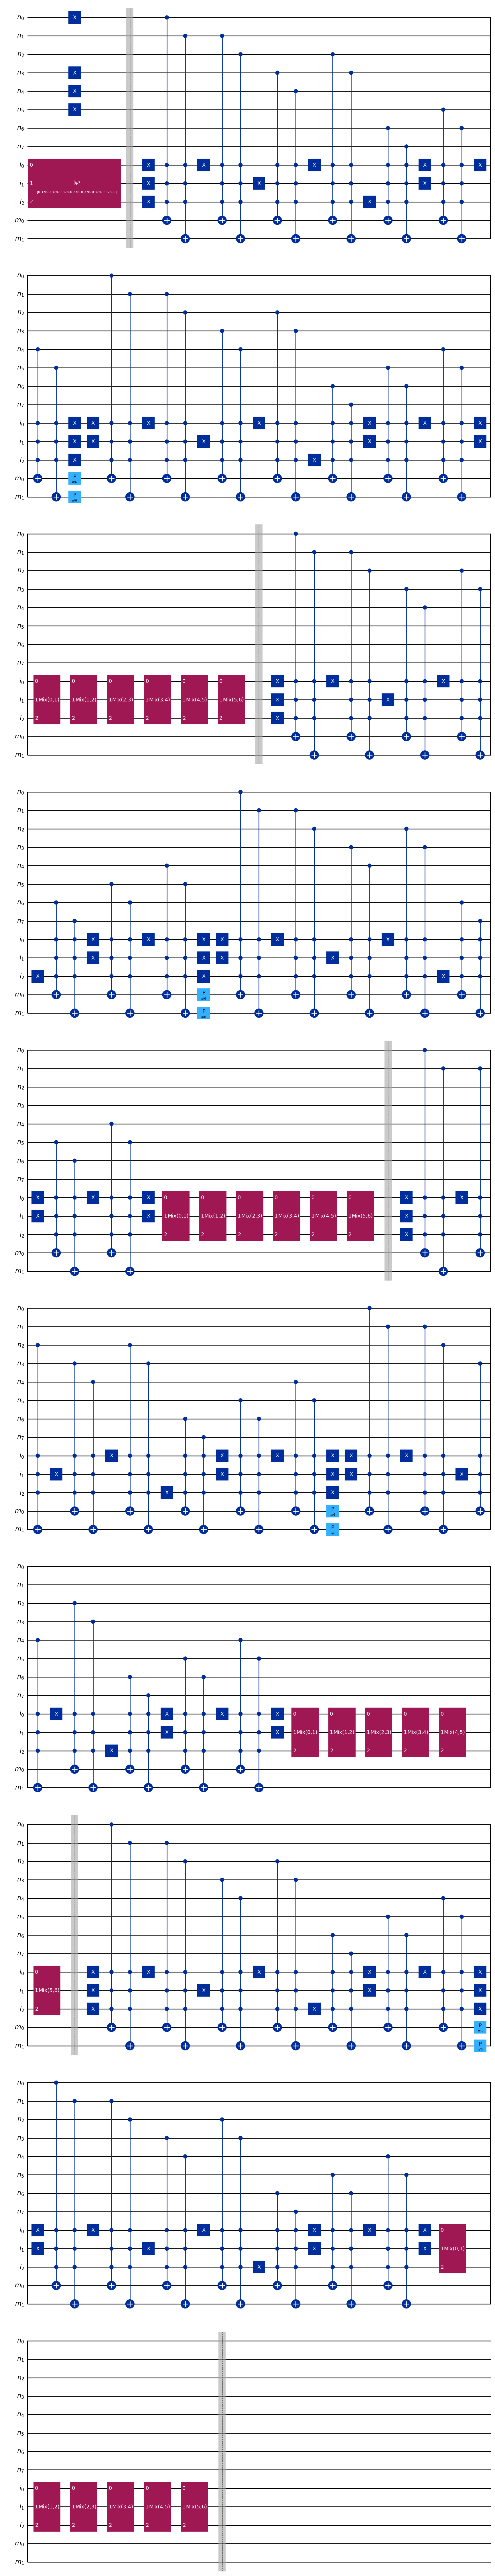

In [6]:
# =========================================================
# Main experiment
# =========================================================

qc_v4, meta_v4, analysis_v4 = run_experiment(
    name="Main V4 cost-phase + local mixer",
    N=N,
    M=M,
    occupied_coords=occupied_coords,
    theta=theta,
    mixer_angle=mixer_angle,
    repetitions=repetitions,
    mixer_method=mixer_method,
    draw=False,
)

qc_v4.draw(output="mpl")

## Small tests

These tests are not formal unit tests: they are small cases used to inspect whether the valid probability increases or decreases when changing `theta`, `mixer_angle`, `repetitions`, and `mixer_method`. If a case does not improve `P_valid`, that does not imply a circuit bug; it means that the selected parameters or mixer are not suitable for that instance.

In [7]:
# Test 1: 1D case with a consecutive occupied block
qc_test_1d, meta_test_1d, analysis_test_1d = run_experiment(
    name="Test 1D: consecutive occupied block",
    N=[8],
    M=[2],
    occupied_coords=[(3,), (4,)],
    theta=np.pi,
    mixer_angle=0.30,
    repetitions=2,
    mixer_method="linear_valid",
)

# Test 2: compact 2D case. Uses 3x3 so Statevector analysis stays lightweight.
qc_test_2d, meta_test_2d, analysis_test_2d = run_experiment(
    name="Compact 2D test: 3x3 with 2x2 window",
    N=[3, 3],
    M=[2, 2],
    occupied_coords=[(0, 0), (2, 2)],
    theta=np.pi / 2,
    mixer_angle=0.28,
    repetitions=2,
    mixer_method="local_geometric",
)

# Test 3: several valid windows in a small and fast-to-simulate 2D grid.
qc_test_multi, meta_test_multi, analysis_test_multi = run_experiment(
    name="2D test: several valid windows",
    N=[3, 3],
    M=[2, 2],
    occupied_coords=[(0, 0), (0, 2)],
    theta=np.pi / 4,
    mixer_angle=0.35,
    repetitions=3,
    mixer_method="local_geometric",
)

# Optional 4x4 case. It may take a while because it uses Statevector over many qubits.
RUN_HEAVY_4X4_TEST = False
if RUN_HEAVY_4X4_TEST:
    qc_test_4x4, meta_test_4x4, analysis_test_4x4 = run_experiment(
        name="Heavy 2D test: 4x4 with 2x2 window",
        N=[4, 4],
        M=[2, 2],
        occupied_coords=[(1, 1), (2, 2)],
        theta=np.pi,
        mixer_angle=0.25,
        repetitions=2,
        mixer_method="local_geometric",
    )




########################################
Experiment: Test 1D: consecutive occupied block
########################################

============ Test 1D: consecutive occupied block ============
N=[8], M=[2], W=7, IDX=3
theta=3.14159, mixer_angle=0.3, repetitions=2
mixer_method=linear_valid
valid_indices=[0, 1, 5, 6]
P_valid_initial = 0.571429
P_valid_after   = 0.612279
P_invalid_after = 0.387721

index | start coordinate | window | C(i) | probability | valid
------|------------------|--------|------|-------------|------
    0 | (0,)             | 00     |    0 |    0.163548 | True
    1 | (1,)             | 00     |    0 |    0.163548 | True
    2 | (2,)             | 01     |    1 |    0.145279 | False
    3 | (3,)             | 11     |    2 |    0.145279 | False
    4 | (4,)             | 10     |    1 |    0.097164 | False
    5 | (5,)             | 00     |    0 |    0.134331 | True
    6 | (6,)             | 00     |    0 |    0.150851 | True


##################################

## Design notes

- The cost phase is implemented as `P(theta)` on each qubit of the register `m` after loading `window_i`. This implements `exp(i theta C(i))` because each occupied cell contributes one phase `theta`.
- The same loader is then applied again to uncompute `m`, leaving the accumulated phase on `idx`.
- The default mixer is local on the graph of valid windows. It does not use Grover's global diffusion operator.
- `rx_all` remains as a simple prototype, but it can transfer amplitude to invalid indices when `W` is not a power of two.
- For large instances, the local mixer based on `UnitaryGate` should be replaced by a more efficient decomposition into native gates or by specialized geometric mixers.

In [8]:
# DISABLED: IBM hardware execution is commented out; simulations only.
# =========================================================
# IBM Quantum submission: ibm_basquecountry backend
# =========================================================
# This cell is intended to be the last cell of the notebook.
# Fill IBM_TOKEN or use a locally saved account; do not store credentials in Git.

# IBM_BACKEND_NAME = "ibm_basquecountry"
# IBM_CHANNEL = "ibm_quantum_platform"
# IBM_TOKEN = ""  # DISABLED: do not store IBM tokens in notebooks.
# IBM_INSTANCE = ""  # DISABLED: optional hub/group/project or CRN, if the account requires it.
# IBM_USE_SAVED_ACCOUNT = False
# IBM_SHOTS = 1024
# IBM_OPTIMIZATION_LEVEL = 1
# IBM_WAIT_FOR_RESULT = False
# IBM_SUBMIT_TESTS = False  # Cambia a True si tambien quieres enviar los circuitos de prueba.


# def _load_ibm_runtime():
#     try:
#         from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
#     except ImportError as exc:
#         raise ImportError(
#             "Falta qiskit-ibm-runtime. Instala las dependencias con: "
#             "pip install -r requirements.txt"
#         ) from exc
#     return QiskitRuntimeService, Sampler


# def _service_from_local_credentials():
#     QiskitRuntimeService, Sampler = _load_ibm_runtime()
#     if IBM_USE_SAVED_ACCOUNT:
#         return QiskitRuntimeService(), Sampler

#     token = IBM_TOKEN.strip()
#     if not token:
#         raise RuntimeError(
#             "Rellena IBM_TOKEN o pon IBM_USE_SAVED_ACCOUNT=True si ya guardaste "
#             "la cuenta con QiskitRuntimeService.save_account(...)."
#         )

#     service_kwargs = {"channel": IBM_CHANNEL, "token": token}
#     if IBM_INSTANCE.strip():
#         service_kwargs["instance"] = IBM_INSTANCE.strip()
#     return QiskitRuntimeService(**service_kwargs), Sampler


# def _backend_num_qubits(backend):
#     num_qubits = getattr(backend, "num_qubits", None)
#     if num_qubits is None and hasattr(backend, "configuration"):
#         num_qubits = backend.configuration().num_qubits
#     return num_qubits


# def add_index_measurements(circuit, metadata, classical_name="c_idx"):
#     """Copies the circuit and measures only the index register i."""
#     from qiskit import ClassicalRegister

#     measured = circuit.copy()
#     idx_register = next((reg for reg in measured.qregs if reg.name == "i"), None)
#     if idx_register is None:
#         raise ValueError("Could not find the quantum index register named 'i'.")

#     if len(idx_register) != metadata["IDX"]:
#         raise ValueError("The size of register i does not match metadata['IDX'].")

#     c_idx = ClassicalRegister(metadata["IDX"], classical_name)
#     measured.add_register(c_idx)
#     for bit, cbit in zip(idx_register, c_idx):
#         measured.measure(bit, cbit)
#     return measured


# def circuits_to_submit_to_ibm():
#     """Returns the prepared programs. By default only submits the main experiment."""
#     if "qc_v4" not in globals() or "meta_v4" not in globals():
#         raise RuntimeError("Ejecuta primero la celda del experimento principal para crear qc_v4 y meta_v4.")

#     programs = [("main_v4", qc_v4, meta_v4)]

#     if IBM_SUBMIT_TESTS:
#         optional_programs = [
#             ("test_1d", "qc_test_1d", "meta_test_1d"),
#             ("test_2d_compact", "qc_test_2d", "meta_test_2d"),
#             ("test_multi", "qc_test_multi", "meta_test_multi"),
#             ("test_4x4", "qc_test_4x4", "meta_test_4x4"),
#         ]
#         for name, circuit_var, meta_var in optional_programs:
#             if circuit_var in globals() and meta_var in globals():
#                 programs.append((name, globals()[circuit_var], globals()[meta_var]))
#     return programs


# def submit_programs_to_ibm():
#     """Transpiles the programs for ibm_basquecountry and submits them with SamplerV2."""
#     from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

#     service, Sampler = _service_from_local_credentials()
#     backend = service.backend(IBM_BACKEND_NAME)
#     backend_qubits = _backend_num_qubits(backend)

#     measured_programs = []
#     for name, circuit, metadata in circuits_to_submit_to_ibm():
#         measured = add_index_measurements(circuit, metadata, classical_name="c_idx")
#         if backend_qubits is not None and measured.num_qubits > backend_qubits:
#             raise ValueError(
#                 f"El circuito {name} necesita {measured.num_qubits} qubits, "
#                 f"pero {IBM_BACKEND_NAME} declara {backend_qubits}."
#             )
#         measured_programs.append((name, measured))

#     pm = generate_preset_pass_manager(
#         backend=backend,
#         optimization_level=IBM_OPTIMIZATION_LEVEL,
#     )

#     names = []
#     isa_circuits = []
#     for name, measured in measured_programs:
#         print(f"Transpilando {name}: {measured.num_qubits} qubits, depth original {measured.depth()}.")
#         isa = pm.run(measured)
#         print(f"  depth ISA {isa.depth()}, size ISA {isa.size()}.")
#         names.append(name)
#         isa_circuits.append(isa)

#     sampler = Sampler(mode=backend)
#     job = sampler.run(isa_circuits, shots=IBM_SHOTS)
#     print(f"Job enviado a {IBM_BACKEND_NAME}: {job.job_id()}")
#     print("Programas enviados:", ", ".join(names))

#     if IBM_WAIT_FOR_RESULT:
#         result = job.result()
#         for name, pub_result in zip(names, result):
#             counts = pub_result.data.c_idx.get_counts()
#             print(f"{name} counts on the idx register:")
#             print(counts)
#     return job


# Run this call after filling the credentials above.
# ibm_job = submit_programs_to_ibm()


In [9]:
# DISABLED: IBM hardware execution is commented out; simulations only.
# =========================================================
# IBM result receipt and interpretation
# =========================================================
# This cell retrieves already submitted jobs and translates the counts measured on idx
# into candidate windows for the problem: start coordinate, window_i, C(i), and validity.

# from datetime import datetime, timezone
# import os

# IBM_RECEIPT_JOB_IDS = []  # If you restarted the kernel, paste job_id strings here, for example: ["abc123..."]
# IBM_RECEIPT_CHANNEL = globals().get("IBM_CHANNEL", "ibm_quantum_platform")
# IBM_RECEIPT_BACKEND_NAME = globals().get("IBM_BACKEND_NAME", "ibm_basquecountry")
# IBM_RECEIPT_INSTANCE = os.environ.get("IBM_QUANTUM_INSTANCE", globals().get("IBM_INSTANCE", ""))
# IBM_RECEIPT_TOKEN = os.environ.get("IBM_QUANTUM_TOKEN", globals().get("IBM_TOKEN", ""))
# IBM_RECEIPT_USE_SAVED_ACCOUNT = globals().get("IBM_USE_SAVED_ACCOUNT", False)
# IBM_RECEIPT_MAX_ROWS = 16


# def _receipt_service():
#     from qiskit_ibm_runtime import QiskitRuntimeService

#     if IBM_RECEIPT_USE_SAVED_ACCOUNT:
#         return QiskitRuntimeService()

#     if not str(IBM_RECEIPT_TOKEN).strip():
#         raise RuntimeError(
#             "Para recuperar jobs, define IBM_QUANTUM_TOKEN en el entorno, "
#             "fill IBM_RECEIPT_TOKEN temporarily, or use IBM_RECEIPT_USE_SAVED_ACCOUNT=True."
#         )

#     kwargs = {"channel": IBM_RECEIPT_CHANNEL, "token": str(IBM_RECEIPT_TOKEN).strip()}
#     if str(IBM_RECEIPT_INSTANCE).strip():
#         kwargs["instance"] = str(IBM_RECEIPT_INSTANCE).strip()
#     return QiskitRuntimeService(**kwargs)


# def _job_id(job):
#     attr = getattr(job, "job_id", None)
#     return attr() if callable(attr) else attr


# def _job_status(job):
#     try:
#         status = job.status()
#     except TypeError:
#         status = job.status
#     return getattr(status, "name", str(status))


# def _job_backend_name(job):
#     backend = None
#     try:
#         backend = job.backend()
#     except Exception:
#         backend = getattr(job, "backend", None)
#     if backend is None:
#         return IBM_RECEIPT_BACKEND_NAME
#     name = getattr(backend, "name", None)
#     return name() if callable(name) else str(name)


# def _counts_from_pub_result(pub_result):
#     data = getattr(pub_result, "data", None)
#     if data is None:
#         raise ValueError("The result does not contain a data field.")

#     if hasattr(data, "c_idx") and hasattr(data.c_idx, "get_counts"):
#         return data.c_idx.get_counts()

#     for field_name in dir(data):
#         if field_name.startswith("_"):
#             continue
#         field = getattr(data, field_name)
#         if hasattr(field, "get_counts"):
#             return field.get_counts()

#     raise ValueError("Could not find a classical register with get_counts().")


# def _bitstring_to_index(bitstring):
#     compact = str(bitstring).replace(" ", "")
#     return int(compact, 2)


# def _programs_for_interpretation():
#     if "circuits_to_submit_to_ibm" in globals():
#         return circuits_to_submit_to_ibm()
#     if "qc_v4" in globals() and "meta_v4" in globals():
#         return [("main_v4", qc_v4, meta_v4)]
#     raise RuntimeError("Run the previous TFG_V4 cells first so meta_v4 and the classical functions are available.")


# def _jobs_for_receipt(service):
#     jobs = []
#     seen = set()

#     if "ibm_job" in globals():
#         jid = _job_id(ibm_job)
#         if jid and jid not in seen:
#             jobs.append(ibm_job)
#             seen.add(jid)

#     for jid in IBM_RECEIPT_JOB_IDS:
#         if jid not in seen:
#             jobs.append(service.job(jid))
#             seen.add(jid)

#     if not jobs:
#         raise RuntimeError(
#             "No hay jobs que recuperar. Si el kernel conserva ibm_job, ejecuta esta celda directamente; "
#             "si no, pega el job_id en IBM_RECEIPT_JOB_IDS."
#         )
#     return jobs


# def _interpret_counts(counts, metadata, title):
#     starts = metadata["starts"]
#     grid_bits = metadata["grid_bits"]
#     N, M, W = metadata["N"], metadata["M"], metadata["W"]
#     valid_indices = set(get_valid_indices(grid_bits, starts, N, M))
#     shots = sum(counts.values())
#     rows = []
#     p_valid = 0.0
#     p_invalid_index = 0.0

#     for bitstring, count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
#         idx_int = _bitstring_to_index(bitstring)
#         prob = count / shots if shots else 0.0
#         if idx_int >= W:
#             p_invalid_index += prob
#             rows.append((bitstring, idx_int, None, None, None, None, count, prob, False, "fuera de rango"))
#             continue

#         start = starts[idx_int]
#         window = window_string_classical(grid_bits, start, N, M)
#         cost = compute_window_cost_classical(grid_bits, start, N, M)
#         is_valid = idx_int in valid_indices
#         if is_valid:
#             p_valid += prob
#         rows.append((bitstring, idx_int, start, window, cost, is_valid, count, prob, is_valid, "valid" if is_valid else "invalid"))

#     print()
#     print(f"===== Interpretacion hardware: {title} =====")
#     print(f"shots = {shots}")
#     print(f"P_valid_hardware = {p_valid:.6f}")
#     print(f"P_invalid_hardware = {1.0 - p_valid:.6f}")
#     if p_invalid_index > 0:
#         print(f"P_indices_fuera_de_rango = {p_invalid_index:.6f}")

#     if "analysis_v4" in globals() and title == "main_v4":
#         print(f"P_valid_statevector = {analysis_v4['P_valid_after']:.6f}")
#         print(f"Delta hardware - statevector = {p_valid - analysis_v4['P_valid_after']:.6f}")

#     print()
#     print("bitstring | index | start | window | C(i) | counts | probability | interpretation")
#     print("----------|-------|-------|--------|------|--------|-------------|----------------")
#     for row in rows[:IBM_RECEIPT_MAX_ROWS]:
#         bitstring, idx_int, start, window, cost, _, count, prob, _, label = row
#         print(f"{str(bitstring):>9} | {idx_int:>5} | {str(start):>5} | {str(window):>6} | {str(cost):>4} | {count:>6} | {prob:>11.6f} | {label}")

#     valid_rows = [row for row in rows if row[8]]
#     if valid_rows:
#         best = max(valid_rows, key=lambda row: row[6])
#         print(
#             f"Solucion candidata dominante: index={best[1]}, start={best[2]}, "
#             f"window={best[3]}, C(i)={best[4]}, frecuencia={best[7]:.6f}."
#         )
#     else:
#         print()
#         print("No valid window was measured in this job.")

#     return {"shots": shots, "P_valid_hardware": p_valid, "rows": rows}


# def retrieve_and_interpret_ibm_jobs():
#     service = _receipt_service()
#     jobs = _jobs_for_receipt(service)
#     programs = _programs_for_interpretation()
#     receipt = []
#     interpretations = []

#     for job in jobs:
#         jid = _job_id(job)
#         status = _job_status(job)
#         backend_name = _job_backend_name(job)
#         stamp = datetime.now(timezone.utc).isoformat()

#         print()
#         print("========== RECIBO IBM QUANTUM ==========")
#         print(f"job_id: {jid}")
#         print(f"backend: {backend_name}")
#         print(f"status: {status}")
#         print(f"retrieved_utc: {stamp}")

#         receipt.append({
#             "job_id": jid,
#             "backend": backend_name,
#             "status": status,
#             "retrieved_utc": stamp,
#         })

#         result = job.result()
#         for program, pub_result in zip(programs, result):
#             name, _circuit, metadata = program
#             counts = _counts_from_pub_result(pub_result)
#             interpretations.append((jid, name, _interpret_counts(counts, metadata, name)))

#     return receipt, interpretations


# ibm_receipts, ibm_interpretations = retrieve_and_interpret_ibm_jobs()


## Analysis 1 — P_valid vs repetitions (oscillation curve)


In [10]:
# =========================================================
# Analysis helpers — V4
# =========================================================
# SLOW: set ANALYSIS_FAST_MODE = False for quick previews on large grids.
# Full thesis mode uses repetitions 1..40 and a 20x20 heatmap grid.

import time
import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.size": 12,
})

VALID_COLOR = "#2ecc71"
INVALID_COLOR = "#e74c3c"
BASELINE_COLOR = "0.45"

ANALYSIS_FAST_MODE = False
ANALYSIS_MAX_REPS = 20 if ANALYSIS_FAST_MODE else 40
ANALYSIS_GRID_POINTS = 10 if ANALYSIS_FAST_MODE else 20
ANALYSIS_THETA_POINTS = 30 if ANALYSIS_FAST_MODE else 60
ANALYSIS_MATRIX_ACCELERATION = True  # exact W-dimensional layer model; set False to force full circuit sweeps.

v4_analysis_results = {}


def v4_analysis_context():
    """Collects the problem definition from the current notebook state."""
    meta = globals().get("meta_v4")
    if meta is not None:
        N0 = list(meta.get("N", globals().get("N")))
        M0 = list(meta.get("M", globals().get("M")))
        starts0 = list(meta.get("starts", valid_starts_nd(N0, M0)))
        grid_bits0 = list(meta.get("grid_bits", build_grid_bits(N0, meta.get("occupied_coords", globals().get("occupied_coords", [])))))
        occupied0 = list(meta.get("occupied_coords", globals().get("occupied_coords", [])))
        mixer0 = meta.get("mixer_method", globals().get("mixer_method", "local_geometric"))
        theta0 = float(globals().get("theta", meta.get("theta", np.pi / 2)))
        beta0 = float(globals().get("mixer_angle", meta.get("mixer_angle", 0.35)))
        transition0 = meta.get("transition_mode", globals().get("transition_mode", "oriented_valid"))
    else:
        N0 = list(globals().get("N"))
        M0 = list(globals().get("M"))
        occupied0 = list(globals().get("occupied_coords", []))
        starts0 = valid_starts_nd(N0, M0)
        grid_bits0 = build_grid_bits(N0, occupied0)
        mixer0 = globals().get("mixer_method", "local_geometric")
        theta0 = float(globals().get("theta", np.pi / 2))
        beta0 = float(globals().get("mixer_angle", 0.35))
        transition0 = globals().get("transition_mode", "oriented_valid")

    costs0 = [compute_window_cost_classical(grid_bits0, s, N0, M0) for s in starts0]
    valid_indices0 = [i for i, c in enumerate(costs0) if c == 0]
    W0 = len(starts0)
    return {
        "N": N0,
        "M": M0,
        "occupied_coords": occupied0,
        "starts": starts0,
        "grid_bits": grid_bits0,
        "costs": costs0,
        "valid_indices": valid_indices0,
        "W": W0,
        "theta": theta0,
        "beta": beta0,
        "mixer_method": mixer0,
        "transition_mode": transition0,
        "P_uniform": len(valid_indices0) / W0 if W0 else 0.0,
    }


def v4_build_circuit(theta_value, beta_value, reps_value):
    ctx = v4_analysis_context()
    try:
        qc, meta = build_cost_phase_mixer_circuit(
            ctx["N"], ctx["M"], ctx["occupied_coords"],
            theta_value, beta_value, reps_value,
            use_cost_phase=globals().get("use_cost_phase", True),
            use_mixer=globals().get("use_mixer", True),
            mixer_method=ctx["mixer_method"],
            add_barriers=False,
        )
        return qc, meta
    except Exception as exc:
        print(f"[V4] skipped circuit build for reps={reps_value}, theta={theta_value:.4g}, beta={beta_value:.4g}: {exc}")
        return None, None


def v4_index_probabilities_from_sv(sv, meta):
    try:
        return index_probabilities_from_statevector(sv, meta)
    except Exception:
        data = np.asarray(sv.data, dtype=complex)
        W0 = int(meta.get("W", len(data)))
        IDX0 = int(meta.get("IDX", int(np.ceil(np.log2(max(W0, 2))))))
        probs = np.zeros(2**IDX0, dtype=float)
        mask = (1 << IDX0) - 1
        shift = int(meta.get("N_tot", 0))
        for basis_idx, amp in enumerate(data):
            probs[(basis_idx >> shift) & mask] += float(abs(amp) ** 2)
        return probs


def v4_p_valid_from_probs(probs, valid_indices):
    return float(sum(probs[i] for i in valid_indices if i < len(probs)))


def v4_simulate_probs(theta_value, beta_value, reps_value):
    qc, meta = v4_build_circuit(theta_value, beta_value, reps_value)
    if qc is None:
        return None, None
    try:
        sv = Statevector.from_instruction(qc)
        return v4_index_probabilities_from_sv(sv, meta), meta
    except Exception as exc:
        print(f"[V4] skipped Statevector extraction: {exc}")
        return None, meta


def v4_two_level_matrix(W, a, b, beta):
    G = np.eye(W, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    G[a, a] = c
    G[b, b] = c
    G[a, b] = s
    G[b, a] = s
    return G


def v4_phase_vector(theta_value):
    ctx = v4_analysis_context()
    costs0 = ctx["costs"]
    return [theta_value * c for c in costs0]


def v4_layer_matrix(theta_value, beta_value):
    ctx = v4_analysis_context()
    W0 = ctx["W"]
    if ctx["mixer_method"] == "rx_all":
        raise ValueError("The W-dimensional layer model is only valid for local two-level mixers, not rx_all.")
    phases0 = v4_phase_vector(theta_value)
    D = np.diag(np.exp(1j * np.asarray(phases0[:W0], dtype=float)))
    U_mix = np.eye(W0, dtype=complex)
    edges = mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])
    for a, b in edges:
        U_mix = v4_two_level_matrix(W0, a, b, beta_value) @ U_mix
    return U_mix @ D


def v4_analytic_probs(theta_value, beta_value, reps_value):
    ctx = v4_analysis_context()
    W0 = ctx["W"]
    psi = np.ones(W0, dtype=complex) / np.sqrt(W0)
    U = v4_layer_matrix(theta_value, beta_value)
    for _ in range(int(reps_value)):
        psi = U @ psi
    return np.abs(psi) ** 2


def v4_p_valid_analytic(theta_value, beta_value, reps_value):
    ctx = v4_analysis_context()
    probs = v4_analytic_probs(theta_value, beta_value, reps_value)
    return v4_p_valid_from_probs(probs, ctx["valid_indices"])


def v4_savefig(fig, stem):
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# =========================================================
# Analysis 1 — P_valid vs repetitions (V4)
# =========================================================

ctx = v4_analysis_context()
reps_values = np.arange(1, ANALYSIS_MAX_REPS + 1)
p_valid_values = []
start_time = time.time()

for r in reps_values:
    try:
        if ANALYSIS_FAST_MODE and ANALYSIS_MATRIX_ACCELERATION:
            p_valid_values.append(v4_p_valid_analytic(ctx["theta"], ctx["beta"], int(r)))
            continue
        probs, meta = v4_simulate_probs(ctx["theta"], ctx["beta"], int(r))
        if probs is None:
            p_valid_values.append(np.nan)
            continue
        p_valid_values.append(v4_p_valid_from_probs(probs, ctx["valid_indices"]))
    except Exception as exc:
        print(f"[V4] repetition point skipped r={r}: {exc}")
        p_valid_values.append(np.nan)

p_valid_values = np.asarray(p_valid_values, dtype=float)
if np.all(np.isnan(p_valid_values)):
    print("[V4] Analysis 1 skipped: no valid simulation points.")
else:
    max_idx = int(np.nanargmax(p_valid_values))
    r_star = int(reps_values[max_idx])
    p_star = float(p_valid_values[max_idx])
    v4_analysis_results["oscillation"] = {
        "reps": reps_values,
        "p_valid": p_valid_values,
        "r_star": r_star,
        "p_star": p_star,
        "P_uniform": ctx["P_uniform"],
        "theta": ctx["theta"],
        "beta": ctx["beta"],
        "elapsed_s": time.time() - start_time,
        "source": "matrix" if (ANALYSIS_FAST_MODE and ANALYSIS_MATRIX_ACCELERATION) else "circuit Statevector",
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(reps_values, p_valid_values, marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(r_star, color="black", linestyle=":", linewidth=1.5, label=f"r*={r_star}")
    ax.annotate(f"max={p_star:.3f}", xy=(r_star, p_star), xytext=(r_star + 1, min(1.0, p_star + 0.08)), arrowprops={"arrowstyle": "->", "lw": 1.0})
    ax.set_xlabel("repetitions r")
    ax.set_ylabel("P_valid")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"P_valid oscillation vs repetitions (theta={ctx['theta']:.3f}, beta={ctx['beta']:.3f})")
    ax.legend()
    fig.tight_layout()
    v4_savefig(fig, "v4_oscillation")
    print(f"[V4] Analysis 1 saved: v4_oscillation.pdf/png; r*={r_star}, P_valid={p_star:.6f}, elapsed={time.time()-start_time:.1f}s")


[V4] Analysis 1 saved: v4_oscillation.pdf/png; r*=4, P_valid=0.898101, elapsed=250.4s


## Analysis 2 — 2D heatmap: P_valid(theta, beta) at fixed r*


In [11]:
# =========================================================
# Analysis 2 — 2D heatmap P_valid(theta, beta) (V4)
# =========================================================

ctx = v4_analysis_context()
r_star = v4_analysis_results.get("oscillation", {}).get("r_star", 4)
theta_values = np.linspace(0, np.pi, ANALYSIS_GRID_POINTS)
beta_values = np.linspace(0, np.pi / 2, ANALYSIS_GRID_POINTS)
heatmap = np.full((len(theta_values), len(beta_values)), np.nan, dtype=float)
start_time = time.time()

for it, th in enumerate(theta_values):
    for ib, be in enumerate(beta_values):
        try:
            if ANALYSIS_MATRIX_ACCELERATION:
                heatmap[it, ib] = v4_p_valid_analytic(th, be, r_star)
            else:
                probs, _meta = v4_simulate_probs(th, be, r_star)
                if probs is not None:
                    heatmap[it, ib] = v4_p_valid_from_probs(probs, ctx["valid_indices"])
        except Exception as exc:
            print(f"[V4] heatmap point skipped theta={th:.4g}, beta={be:.4g}: {exc}")

if np.all(np.isnan(heatmap)):
    print("[V4] Analysis 2 skipped: heatmap is empty.")
else:
    max_pos = np.unravel_index(np.nanargmax(heatmap), heatmap.shape)
    theta_star_heat = float(theta_values[max_pos[0]])
    beta_star_heat = float(beta_values[max_pos[1]])
    p_star_heat = float(heatmap[max_pos])
    v4_analysis_results["heatmap"] = {
        "theta_values": theta_values,
        "beta_values": beta_values,
        "heatmap": heatmap,
        "theta_star": theta_star_heat,
        "beta_star": beta_star_heat,
        "p_star": p_star_heat,
        "r_star": r_star,
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    im = ax.imshow(
        heatmap,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[beta_values[0] / np.pi, beta_values[-1] / np.pi, theta_values[0] / np.pi, theta_values[-1] / np.pi],
    )
    ax.scatter([beta_star_heat / np.pi], [theta_star_heat / np.pi], marker="*", s=160, color="white", edgecolor="black", linewidth=0.8, label="global max")
    ax.set_xlabel("beta / pi")
    ax.set_ylabel("theta / pi")
    ax.set_title(f"P_valid heatmap at r={r_star} — V4")
    ax.legend(loc="upper right")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("P_valid")
    fig.tight_layout()
    v4_savefig(fig, "v4_heatmap")
    print(f"[V4] Analysis 2 saved: v4_heatmap.pdf/png; theta*={theta_star_heat:.4f}, beta*={beta_star_heat:.4f}, P_valid={p_star_heat:.6f}, elapsed={time.time()-start_time:.1f}s")


[V4] Analysis 2 saved: v4_heatmap.pdf/png; theta*=0.4960, beta*=0.2480, P_valid=0.886460, elapsed=0.7s


## Analysis 3 — Eigenvalue spectrum and period prediction (Method 2)


In [12]:
# =========================================================
# Analysis 3 — Eigenvalue spectrum and period prediction (V4)
# =========================================================

ctx = v4_analysis_context()
try:
    U_layer = v4_layer_matrix(ctx["theta"], ctx["beta"])
    eigvals, eigvecs = np.linalg.eig(U_layer)
    unit_t = np.linspace(0, 2 * np.pi, 400)

    analytical_reps = np.arange(1, 61)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    analytical_curve = []
    psi_r = psi.copy()
    for _r in analytical_reps:
        psi_r = U_layer @ psi_r
        analytical_curve.append(v4_p_valid_from_probs(np.abs(psi_r) ** 2, ctx["valid_indices"]))
    analytical_curve = np.asarray(analytical_curve)

    osc = v4_analysis_results.get("oscillation", {})
    v4_analysis_results["spectrum"] = {
        "U_layer": U_layer,
        "eigvals": eigvals,
        "analytical_reps": analytical_reps,
        "analytical_curve": analytical_curve,
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.cos(unit_t), np.sin(unit_t), color="0.6", linewidth=1.2, label="unit circle")
    sc = axes[0].scatter(eigvals.real, eigvals.imag, c=eigvals.imag, cmap="viridis", s=55, zorder=3)
    axes[0].set_aspect("equal", adjustable="box")
    axes[0].set_xlabel("Re(lambda)")
    axes[0].set_ylabel("Im(lambda)")
    axes[0].set_title(f"Eigenvalue spectrum of one layer — V4")
    axes[0].legend()
    fig.colorbar(sc, ax=axes[0], label="Im(lambda)")

    axes[1].plot(analytical_reps, analytical_curve, color="black", linewidth=2, label="matrix prediction")
    if osc:
        axes[1].plot(osc["reps"], osc["p_valid"], marker="o", linestyle="none", color=VALID_COLOR, label="circuit Statevector")
        axes[1].axhline(osc["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[1].set_xlabel("repetitions r")
    axes[1].set_ylabel("P_valid")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Analytical period prediction")
    axes[1].legend()

    fig.tight_layout()
    v4_savefig(fig, "v4_spectrum")
    print(f"[V4] Analysis 3 saved: v4_spectrum.pdf/png")
except Exception as exc:
    print(f"[V4] Analysis 3 skipped: {exc}")


[V4] Analysis 3 saved: v4_spectrum.pdf/png


## Analysis 4 — Optimal angle scan: P_valid vs theta at fixed beta and r*


In [13]:
# =========================================================
# Analysis 4 — Optimal angle scan P_valid(theta) (V4)
# =========================================================

ctx = v4_analysis_context()
r_star = v4_analysis_results.get("oscillation", {}).get("r_star", 4)
theta_scan_values = np.linspace(0, 2 * np.pi, ANALYSIS_THETA_POINTS)
theta_scan = np.full(len(theta_scan_values), np.nan, dtype=float)
start_time = time.time()

for i, th in enumerate(theta_scan_values):
    try:
        if ANALYSIS_MATRIX_ACCELERATION:
            theta_scan[i] = v4_p_valid_analytic(th, ctx["beta"], r_star)
        else:
            probs, _meta = v4_simulate_probs(th, ctx["beta"], r_star)
            if probs is not None:
                theta_scan[i] = v4_p_valid_from_probs(probs, ctx["valid_indices"])
    except Exception as exc:
        print(f"[V4] theta point skipped theta={th:.4g}: {exc}")

if np.all(np.isnan(theta_scan)):
    print("[V4] Analysis 4 skipped: theta scan is empty.")
else:
    max_idx = int(np.nanargmax(theta_scan))
    theta_star_scan = float(theta_scan_values[max_idx])
    p_star_scan = float(theta_scan[max_idx])
    v4_analysis_results["theta_scan"] = {
        "theta_values": theta_scan_values,
        "p_valid": theta_scan,
        "theta_star": theta_star_scan,
        "p_star": p_star_scan,
        "r_star": r_star,
        "beta": ctx["beta"],
    }

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(theta_scan_values / np.pi, theta_scan, color=VALID_COLOR, linewidth=2, label="P_valid")
    ax.axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    ax.axvline(theta_star_scan / np.pi, color="black", linestyle=":", linewidth=1.5, label=f"theta*={theta_star_scan/np.pi:.2f} pi")
    ax.annotate(f"max={p_star_scan:.3f}", xy=(theta_star_scan / np.pi, p_star_scan), xytext=(theta_star_scan / np.pi + 0.08, min(1.0, p_star_scan + 0.08)), arrowprops={"arrowstyle": "->", "lw": 1.0})
    ax.set_xlabel("theta / pi")
    ax.set_ylabel("P_valid")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"P_valid vs theta at beta={ctx['beta']:.3f}, r={r_star} — V4")
    ax.legend()
    fig.tight_layout()
    v4_savefig(fig, "v4_theta_scan")
    print(f"[V4] Analysis 4 saved: v4_theta_scan.pdf/png; theta*={theta_star_scan:.4f}, P_valid={p_star_scan:.6f}, elapsed={time.time()-start_time:.1f}s")


[V4] Analysis 4 saved: v4_theta_scan.pdf/png; theta*=0.5325, P_valid=0.898732, elapsed=0.4s


## Analysis 5 — Summary dashboard


In [14]:
# =========================================================
# Analysis 5 — Summary dashboard (V4)
# =========================================================

ctx = v4_analysis_context()
try:
    osc = v4_analysis_results.get("oscillation")
    hm = v4_analysis_results.get("heatmap")
    scan = v4_analysis_results.get("theta_scan")
    if osc is None or hm is None or scan is None:
        raise RuntimeError("Run analyses 1, 2 and 4 before the dashboard.")

    r_star = int(osc["r_star"])
    theta_opt = float(scan["theta_star"])
    beta_opt = float(hm["beta_star"])
    final_probs = v4_analytic_probs(theta_opt, beta_opt, r_star)

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle("V4 Analysis Summary", fontsize=16)

    axes[0, 0].plot(osc["reps"], osc["p_valid"], marker="o", linewidth=2, color=VALID_COLOR, label="P_valid")
    axes[0, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[0, 0].axvline(r_star, color="black", linestyle=":", linewidth=1.5, label=f"r*={r_star}")
    axes[0, 0].set_xlabel("repetitions r")
    axes[0, 0].set_ylabel("P_valid")
    axes[0, 0].set_ylim(0, 1.05)
    axes[0, 0].set_title("Oscillation curve")
    axes[0, 0].legend()

    theta_values = hm["theta_values"]
    beta_values = hm["beta_values"]
    im = axes[0, 1].imshow(
        hm["heatmap"],
        origin="lower",
        aspect="auto",
        cmap="viridis",
        extent=[beta_values[0] / np.pi, beta_values[-1] / np.pi, theta_values[0] / np.pi, theta_values[-1] / np.pi],
    )
    axes[0, 1].scatter([hm["beta_star"] / np.pi], [hm["theta_star"] / np.pi], marker="*", s=150, color="white", edgecolor="black", linewidth=0.8)
    axes[0, 1].set_xlabel("beta / pi")
    axes[0, 1].set_ylabel("theta / pi")
    axes[0, 1].set_title("Heatmap")
    cbar = fig.colorbar(im, ax=axes[0, 1])
    cbar.set_label("P_valid")

    axes[1, 0].plot(scan["theta_values"] / np.pi, scan["p_valid"], color=VALID_COLOR, linewidth=2, label="P_valid")
    axes[1, 0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
    axes[1, 0].axvline(scan["theta_star"] / np.pi, color="black", linestyle=":", linewidth=1.5, label="theta*")
    axes[1, 0].set_xlabel("theta / pi")
    axes[1, 0].set_ylabel("P_valid")
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].set_title("Theta scan")
    axes[1, 0].legend()

    colors = [VALID_COLOR if i in ctx["valid_indices"] else INVALID_COLOR for i in range(ctx["W"])]
    axes[1, 1].bar(np.arange(ctx["W"]), final_probs[:ctx["W"]], color=colors)
    axes[1, 1].axhline(1 / ctx["W"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform 1/W")
    axes[1, 1].set_xlabel("window index i")
    axes[1, 1].set_ylabel("probability")
    axes[1, 1].set_ylim(0, max(1 / ctx["W"] * 1.5, float(np.max(final_probs[:ctx["W"]])) * 1.2))
    axes[1, 1].set_title("Final probability per index")
    axes[1, 1].legend()

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    v4_savefig(fig, "v4_summary")
    print(f"[V4] Analysis 5 saved: v4_summary.pdf/png")
except Exception as exc:
    print(f"[V4] Analysis 5 skipped: {exc}")


[V4] Analysis 5 saved: v4_summary.pdf/png


## Analysis 6 — Deep multi-instance benchmark

This section runs a broader benchmark beyond the default example. It evaluates longer 1D arrays, a medium 2D grid, and a small 3D grid. The benchmark uses the exact W-dimensional layer model, which is much faster than repeatedly simulating all grid/window qubits and is valid for the local two-level mixers used here.

In [15]:
# =========================================================
# Analysis 6 — Deep multi-instance benchmark (V4)
# =========================================================
# This benchmark is intended for long unattended runs. It uses the exact W-dimensional
# one-layer model, so 2D/3D cases remain tractable while preserving the index dynamics.

import csv
import time
import numpy as np
import matplotlib.pyplot as plt

DEEP_MAX_REPS = 80
DEEP_GRID_POINTS = 25
DEEP_THETA_VALUES = np.linspace(0, np.pi, DEEP_GRID_POINTS)
DEEP_BETA_VALUES = np.linspace(0, np.pi / 2, DEEP_GRID_POINTS)

DEEP_CASES = [
    {
        "name": "1d_long_clustered_blocks",
        "N": [32],
        "M": [4],
        "occupied_coords": [(i,) for i in range(0, 6)] + [(i,) for i in range(14, 19)] + [(i,) for i in range(28, 32)],
        "mixer_method": "linear_valid",
        "description": "Long 1D array with three occupied clusters.",
    },
    {
        "name": "2d_medium_clustered_obstacles",
        "N": [6, 6],
        "M": [2, 2],
        "occupied_coords": [(0, 0), (0, 1), (1, 0), (1, 1), (2, 3), (2, 4), (3, 3), (4, 0), (4, 1), (5, 0), (5, 1), (5, 5)],
        "mixer_method": "local_geometric",
        "description": "2D grid with corner blocks and a central obstacle.",
    },
    {
        "name": "3d_small_clustered_obstacles",
        "N": [4, 4, 3],
        "M": [2, 2, 2],
        "occupied_coords": [(0, 0, 0), (0, 0, 1), (0, 1, 0), (3, 3, 2), (3, 2, 2), (2, 3, 2)],
        "mixer_method": "local_geometric",
        "description": "Small 3D grid with two clusters and interior noise.",
    },
]


def v4_deep_context(case):
    N_case = list(case["N"])
    M_case = list(case["M"])
    occupied_case = list(case["occupied_coords"])
    validate_problem(N_case, M_case)
    starts_case = valid_starts_nd(N_case, M_case)
    grid_bits_case = build_grid_bits(N_case, occupied_case)
    costs_case = [compute_window_cost_classical(grid_bits_case, s, N_case, M_case) for s in starts_case]
    valid_indices_case = [i for i, c in enumerate(costs_case) if c == 0]
    if not valid_indices_case:
        raise ValueError(f"Case {case['name']} has no valid windows; change occupied_coords.")
    return {
        "name": case["name"],
        "N": N_case,
        "M": M_case,
        "occupied_coords": occupied_case,
        "starts": starts_case,
        "grid_bits": grid_bits_case,
        "costs": costs_case,
        "valid_indices": valid_indices_case,
        "W": len(starts_case),
        "P_uniform": len(valid_indices_case) / len(starts_case),
        "mixer_method": case.get("mixer_method", "local_geometric"),
        "description": case.get("description", ""),
    }


def v4_deep_two_level_matrix(W, a, b, beta):
    G = np.eye(W, dtype=complex)
    c = np.cos(beta)
    s = -1j * np.sin(beta)
    G[a, a] = c
    G[b, b] = c
    G[a, b] = s
    G[b, a] = s
    return G


def v4_deep_phase_vector(ctx, theta_value, mode):
    return [theta_value * c for c in ctx["costs"]]


def v4_deep_layer_matrix(ctx, theta_value, beta_value, mode):
    phases_case = v4_deep_phase_vector(ctx, theta_value, mode)
    D = np.diag(np.exp(1j * np.asarray(phases_case, dtype=float)))
    U_mix = np.eye(ctx["W"], dtype=complex)
    edges = mixer_edges_from_starts(ctx["starts"], ctx["N"], ctx["mixer_method"])
    for a, b in edges:
        U_mix = v4_deep_two_level_matrix(ctx["W"], a, b, beta_value) @ U_mix
    return U_mix @ D


def v4_deep_probabilities(ctx, theta_value, beta_value, reps_value, mode):
    U = v4_deep_layer_matrix(ctx, theta_value, beta_value, mode)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    for _ in range(int(reps_value)):
        psi = U @ psi
    return np.abs(psi) ** 2


def v4_deep_p_valid(ctx, probs):
    return float(sum(probs[i] for i in ctx["valid_indices"]))


def v4_deep_curve(ctx, theta_value, beta_value, mode, max_reps=DEEP_MAX_REPS):
    U = v4_deep_layer_matrix(ctx, theta_value, beta_value, mode)
    psi = np.ones(ctx["W"], dtype=complex) / np.sqrt(ctx["W"])
    reps = np.arange(1, max_reps + 1)
    curve = []
    for _r in reps:
        psi = U @ psi
        curve.append(v4_deep_p_valid(ctx, np.abs(psi) ** 2))
    return reps, np.asarray(curve)


def v4_deep_heatmap(ctx, r_star, mode):
    heat = np.zeros((len(DEEP_THETA_VALUES), len(DEEP_BETA_VALUES)), dtype=float)
    for it, th in enumerate(DEEP_THETA_VALUES):
        for ib, be in enumerate(DEEP_BETA_VALUES):
            probs = v4_deep_probabilities(ctx, th, be, r_star, mode)
            heat[it, ib] = v4_deep_p_valid(ctx, probs)
    return heat


def v4_deep_savefig(fig, stem):
    fig.savefig(f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(f"{stem}.png", dpi=200, bbox_inches="tight")
    plt.close(fig)


def v4_run_deep_benchmark():
    theta_default = float(globals().get("theta", np.pi / 3))
    beta_default = float(globals().get("mixer_angle", 0.35))
    rows = []
    start_time = time.time()

    for case in DEEP_CASES:
        ctx = v4_deep_context(case)
        print()
        print(f"[V4] Deep case: {ctx['name']} | N={ctx['N']}, M={ctx['M']}, W={ctx['W']}, valid={len(ctx['valid_indices'])}, uniform={ctx['P_uniform']:.4f}")

        for mode in case.get('transition_modes', ['cost_phase']):
            reps, curve = v4_deep_curve(ctx, theta_default, beta_default, mode)
            r_star = int(reps[int(np.argmax(curve))])
            p_r_star = float(np.max(curve))
            heat = v4_deep_heatmap(ctx, r_star, mode)
            max_pos = np.unravel_index(int(np.argmax(heat)), heat.shape)
            theta_star = float(DEEP_THETA_VALUES[max_pos[0]])
            beta_star = float(DEEP_BETA_VALUES[max_pos[1]])
            p_heat_star = float(heat[max_pos])
            final_probs = v4_deep_probabilities(ctx, theta_star, beta_star, r_star, mode)

            safe_name = f"v4_deep_{ctx['name']}_{mode}".replace(" ", "_")
            fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
            fig.suptitle(f"V4 deep benchmark — {ctx['name']} — {mode}", fontsize=15)

            axes[0].plot(reps, curve, color=VALID_COLOR, marker="o", markersize=3, linewidth=1.8, label="P_valid")
            axes[0].axhline(ctx["P_uniform"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform K/W")
            axes[0].axvline(r_star, color="black", linestyle=":", linewidth=1.3, label=f"r*={r_star}")
            axes[0].set_xlabel("repetitions r")
            axes[0].set_ylabel("P_valid")
            axes[0].set_ylim(0, 1.05)
            axes[0].set_title("Oscillation")
            axes[0].legend()

            im = axes[1].imshow(
                heat,
                origin="lower",
                aspect="auto",
                cmap="viridis",
                extent=[DEEP_BETA_VALUES[0] / np.pi, DEEP_BETA_VALUES[-1] / np.pi, DEEP_THETA_VALUES[0] / np.pi, DEEP_THETA_VALUES[-1] / np.pi],
            )
            axes[1].scatter([beta_star / np.pi], [theta_star / np.pi], marker="*", s=150, color="white", edgecolor="black", linewidth=0.8)
            axes[1].set_xlabel("beta / pi")
            axes[1].set_ylabel("theta / pi")
            axes[1].set_title(f"Heatmap at r={r_star}")
            fig.colorbar(im, ax=axes[1], label="P_valid")

            colors = [VALID_COLOR if i in ctx["valid_indices"] else INVALID_COLOR for i in range(ctx["W"])]
            axes[2].bar(np.arange(ctx["W"]), final_probs, color=colors)
            axes[2].axhline(1 / ctx["W"], color=BASELINE_COLOR, linestyle="--", linewidth=1.5, label="uniform 1/W")
            axes[2].set_xlabel("window index i")
            axes[2].set_ylabel("probability")
            axes[2].set_title("Final distribution at optimum")
            axes[2].legend()

            fig.tight_layout(rect=[0, 0, 1, 0.92])
            v4_deep_savefig(fig, safe_name)

            rows.append({
                "case": ctx["name"],
                "mode": mode,
                "dimension": len(ctx["N"]),
                "N": str(ctx["N"]),
                "M": str(ctx["M"]),
                "W": ctx["W"],
                "valid_windows": len(ctx["valid_indices"]),
                "P_uniform": ctx["P_uniform"],
                "theta_default": theta_default,
                "beta_default": beta_default,
                "r_star_default_angles": r_star,
                "P_valid_at_r_star_default_angles": p_r_star,
                "theta_star_heatmap": theta_star,
                "beta_star_heatmap": beta_star,
                "P_valid_heatmap_star": p_heat_star,
                "figure": safe_name,
            })
            print(f"  mode={mode} | r*={r_star} | P_default={p_r_star:.4f} | theta*={theta_star/np.pi:.3f}pi | beta*={beta_star/np.pi:.3f}pi | P_best={p_heat_star:.4f}")

    csv_name = "v4_deep_benchmark.csv"
    with open(csv_name, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)

    labels = [f"{row['case']}\n{row['mode']}" for row in rows]
    x = np.arange(len(rows))
    fig, axes = plt.subplots(2, 1, figsize=(14, 9))
    axes[0].bar(x - 0.18, [row["P_uniform"] for row in rows], width=0.36, color="0.7", label="uniform K/W")
    axes[0].bar(x + 0.18, [row["P_valid_heatmap_star"] for row in rows], width=0.36, color=VALID_COLOR, label="best P_valid")
    axes[0].set_ylabel("P_valid")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title(f"V4 deep benchmark: best probability by case")
    axes[0].legend()

    axes[1].bar(x, [row["r_star_default_angles"] for row in rows], color="#3498db")
    axes[1].set_ylabel("best repetition r*")
    axes[1].set_title("Best repetition using default angles")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=35, ha="right")

    fig.tight_layout()
    v4_deep_savefig(fig, "v4_deep_benchmark_summary")
    print(f"[V4] Deep benchmark saved: {csv_name}, v4_deep_benchmark_summary.pdf/png")
    print(f"[V4] Total elapsed: {time.time() - start_time:.1f}s")
    return rows


v4_deep_benchmark_rows = v4_run_deep_benchmark()



[V4] Deep case: 1d_long_clustered_blocks | N=[32], M=[4], W=29, valid=11, uniform=0.3793
  mode=cost_phase | r*=4 | P_default=0.6474 | theta*=0.167pi | beta*=0.167pi | P_best=0.7396

[V4] Deep case: 2d_medium_clustered_obstacles | N=[6, 6], M=[2, 2], W=25, valid=8, uniform=0.3200
  mode=cost_phase | r*=28 | P_default=0.7643 | theta*=0.208pi | beta*=0.333pi | P_best=0.7537

[V4] Deep case: 3d_small_clustered_obstacles | N=[4, 4, 3], M=[2, 2, 2], W=18, valid=12, uniform=0.6667
  mode=cost_phase | r*=45 | P_default=0.9473 | theta*=0.708pi | beta*=0.167pi | P_best=0.9427
[V4] Deep benchmark saved: v4_deep_benchmark.csv, v4_deep_benchmark_summary.pdf/png
[V4] Total elapsed: 5.0s
